# **Final**

TypeError: cannot unpack non-iterable float object

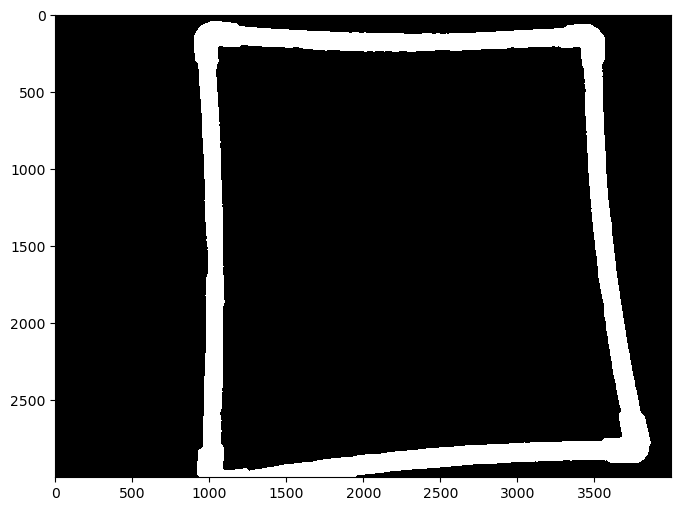

In [ ]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Dict, Tuple
import os

# Processing tensor
def to_mask2d(m_or_path: Union[str, torch.Tensor, np.ndarray]) -> np.ndarray:
    """Accepts a .pt path OR a torch.Tensor OR a NumPy array. Returns 2D binary mask {0,1}."""
    if isinstance(m_or_path, str):
        t = torch.load(m_or_path, map_location="cpu")
        m = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)
    elif isinstance(m_or_path, torch.Tensor):
        m = m_or_path.detach().cpu().numpy()
    else:
        m = np.asarray(m_or_path)
    m = (np.squeeze(m) > 0).astype(np.uint8)
    if m.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {m.shape}")
    return m

# Finding corners
def point_bottom_right(m: np.ndarray) -> Tuple[int, int]:
    """Bottom-right by maximizing x*y."""
    ys, xs = np.where(m == 1)
    if ys.size == 0: raise ValueError("Mask is empty.")
    i = (ys.astype(np.int64) * xs.astype(np.int64)).argmax()
    return int(ys[i]), int(xs[i])

def point_top_left(m: np.ndarray) -> Tuple[int, int]:
    """Top-left by minimizing (x+y) with x>0,y>0."""
    ys, xs = np.where(m == 1)
    keep = (ys > 0) & (xs > 0)
    ys, xs = ys[keep], xs[keep]
    if ys.size == 0: raise ValueError("No white pixels with x>0 and y>0.")
    sums = ys.astype(np.int64) + xs.astype(np.int64)
    min_sum = sums.min()
    idx = np.where(sums == min_sum)[0]
    y_sel = int(ys[idx].min())
    x_sel = int(xs[idx][ys[idx] == y_sel].min())
    return y_sel, x_sel

def point_top_right(m: np.ndarray) -> Tuple[int, int]:
    """Top-right by maximizing (x - y); tie-break largest x, then smallest y."""
    ys, xs = np.where(m == 1)
    diffs = xs.astype(np.int64) - ys.astype(np.int64)
    best = diffs.max()
    keep = (diffs == best)
    xs_t, ys_t = xs[keep], ys[keep]
    x_sel = int(xs_t.max())
    y_sel = int(ys_t[xs_t == x_sel].min())
    return y_sel, x_sel

def point_bottom_left(m: np.ndarray) -> Tuple[int, int]:
    """Bottom-left by maximizing (y - x); tie-break largest y, then smallest x."""
    ys, xs = np.where(m == 1)
    diffs = ys.astype(np.int64) - xs.astype(np.int64)
    best = diffs.max()
    keep = (diffs == best)
    ys_t, xs_t = ys[keep], xs[keep]
    y_sel = int(ys_t.max())
    x_sel = int(xs_t[ys_t == y_sel].min())
    return y_sel, x_sel

def find_four_points(m_or_path: Union[str, torch.Tensor, np.ndarray]) -> Dict[str, Tuple[int,int]]:
    """Return dict with TL, TR, BR, BL as (y,x)."""
    m = to_mask2d(m_or_path)
    return {
        "TL": point_top_left(m),
        "TR": point_top_right(m),
        "BR": point_bottom_right(m),
        "BL": point_bottom_left(m),
    }

# Computing distance
def compute_distances(m_or_path):
    """
    Given points dict with keys {'TL','TR','BR','BL'} -> (y,x),
    return Euclidean distances (pixels) for:
      TR–TL, TR–BR, TL–BL, BR–BL, TL–BR, TR–BL.
    """
    points = find_four_points(m_or_path)

    def d(p, q):
        (y1,x1), (y2,x2) = points[p], points[q]
        return float(np.hypot(x2 - x1, y2 - y1))

    return {
        "TR_TL": d("TR","TL"),
        "TR_BR": d("TR","BR"),
        "TL_BL": d("TL","BL"),
        "BR_BL": d("BR","BL"),
        "TL_BR": d("TL","BR"),
        "TR_BL": d("TR","BL"),
    }


# Computing pixel to cm ratio for the sides and diagonals
def pix_to_cm_square(points, side = 53, diagonal = 75):
  distances = compute_distances(points).copy()
  for k, l in distances.items():
    if k == "TL_BR" or "TR_BL":
      l = l/diagonal
    else:
      l = l/side
  return print(distances)

# Plot
def plot_points_and_distances(m_or_path: Union[str, torch.Tensor, np.ndarray],
                              points: Dict[str, Tuple[int,int]]) -> None:
    """Overlay TL/TR/BR/BL and requested segments with labels on the mask."""
    m = to_mask2d(m_or_path)
    H, W = m.shape
    fig, ax = plt.subplots(figsize=(8, 8 * H / W))
    ax.imshow(m, cmap="gray", interpolation="nearest", origin="upper",
              extent=(-0.5, W - 0.5, H - 0.5, -0.5))

    # plot points
    for k,(y,x) in points.items():
        ax.scatter([x],[y], s=80)
        ax.annotate(f"{k} ({y},{x})", xy=(x,y), xytext=(x+12,y+12),
                    arrowprops=dict(arrowstyle="->"))

    # draw requested pairs
    pairs = [("TR","TL"),("TR","BR"),("TL","BL"),("BR","BL"),("TL","BR"),("TR","BL")]
    for a,b in pairs:
        (y1,x1),(y2,x2) = points[a], points[b]
        ax.plot([x1,x2],[y1,y2], linewidth=2)
        xm, ym = (x1+x2)/2, (y1+y2)/2
        ax.text(xm+5, ym+5, f"{a}-{b}: {np.hypot(x2-x1,y2-y1):.2f}px")

    # grid
    major, minor = 50, 10
    ax.set_xticks(np.arange(0, W, major))
    ax.set_xticks(np.arange(0, W, minor), minor=True)
    ax.set_yticks(np.arange(0, H, major))
    ax.set_yticks(np.arange(0, H, minor), minor=True)
    ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.20)

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xlabel("x (pixels)"); ax.set_ylabel("y (pixels)")
    ax.set_title("Four points & distances")
    plt.tight_layout(); plt.show()


# Use
dists = compute_distances("data/improved_masks/GA 1_PB100651_improved.pt")
plot_points_and_distances("data/improved_masks/GA 1_PB100651_improved.pt", pts)

In [ ]:
# Computing pixel to cm^2 ratio for the sides and diagonals
def pix_to_cm_square(m_or_path, width_side = 53, height_side = 53):
  distances = compute_distances(m_or_path).copy()

  # Calculate diagonal using Pythagorean theorem
  diagonal = float(np.hypot(width_side, height_side))

  for k, l in distances.items():
    # If the distance is a diagonal
    if k == "TL_BR" or k == "TR_BL":
        distances[k] = (diagonal/l)**2
    # If it is a width side
    elif k == "TR_TL" or k == "BR_BL":
        distances[k] = (width_side/l)**2
    # If it is a height side
    elif k == "TL_BL" or k == "TR_BR":
        distances[k] = (height_side/l)**2

  return distances

pix_to_cm_square("data/improved_masks/GA 1_PB100651_improved.pt")

{'TR_TL': 0.00042126896891382946,
 'TR_BR': 0.00035741655901120435,
 'TL_BL': 0.0003258527941152076,
 'BR_BL': 0.0003369815070451209,
 'TL_BR': 0.0003470272158781073,
 'TR_BL': 0.00037006779921378046}

## **Only function you need to call to go from mask -> pix_to_cm^2**

In [36]:
# Filtering for outliers and getting final pixel to cm^2 ratio

def median_band_average_from_cm_ratio(m_or_path, pct = 0.08):
    """
    Return the average of values within [median - pct*median, median + pct*median].
    m_or_path: mask path or tensor.
    pct: fraction for tolerance (e.g., 0.08 for 8%).
    """
    distances = pix_to_cm_square(m_or_path)
    vals = list(distances.values())
    if len(vals) != 6:
        raise ValueError(f"Expected 6 values, got {len(vals)}")

    s = sorted(vals)
    median = 0.5 * (s[2] + s[3])
    tol = pct * median
    lo, hi = median - tol, median + tol

    # All the kept values within the band
    kept = [v for v in vals if lo <= v <= hi]
    return (sum(kept) / len(kept)) if kept else None

median_band_average_from_cm_ratio("data/improved_masks/GA 2_Copy of PB100699_improved.pt", pct = 0.05)

0.000331945233976533

# Testing

In [52]:
# Load ground truth data (change path)
df_gt = pd.read_csv("/Users/stanimir/Desktop/IBF_masks/data/groundtruth_results.csv")

# Write a function that gets only the part of the string before "-2025" appears in the strings from the column folder and PB100662.JPG from jpg_filename_only and returns data/improved_masks/GA 1_PB100662_improved.pt
def get_improved_mask_path(row: pd.Series) -> str:
    folder_name = row['folder'].split('-2025')[0]
    jpg_filename = row['jpg_filename_only']
    base_name = jpg_filename.split('.')[0]
    return f"data/improved_masks/{folder_name}_{base_name}_improved.pt"


# Write a function that iterates over the values in the column jpg_filename_only in df_gt and applies median_band_average_from_cm_ratio to each corresponding improved mask path, collecting the results in a new DataFrame.
def process_ground_truth(df_gt: pd.DataFrame) -> pd.DataFrame:
    results = []
    for _, row in df_gt.iterrows():
        original_filename = row['jpg_filename_only']
        improved_mask_path = get_improved_mask_path(original_filename)
        median_value = median_band_average_from_cm_ratio(improved_mask_path)
        results.append({
            'jpg_filename_only': original_filename,
            'improved_mask_path': improved_mask_path,
            'median_cm_ratio': median_value
        })
    return pd.DataFrame(results)

In [ ]:
def get_improved_mask_path(row: pd.Series) -> str:
    folder_name = row['folder'].split('-2025')[0].strip()
    jpg_filename = row['jpg_filename_only']
    base_name = jpg_filename.split('.')[0]
    return f"data/improved_masks/{folder_name}_{base_name}_improved.pt"



{'TR_TL': 2719.2002500735393, 'TR_BR': 2951.4342276256134, 'TL_BL': 2987.1285543143267, 'BR_BL': 2440.0739742884844, 'TL_BR': 4098.781526258749, 'TR_BL': 3755.511283433988}


AttributeError: 'NoneType' object has no attribute 'values'

In [57]:
df_predict_gt = process_ground_truth(df_gt)
df_predict_gt

{'TR_TL': 2719.2002500735393, 'TR_BR': 2951.4342276256134, 'TL_BL': 2987.1285543143267, 'BR_BL': 2440.0739742884844, 'TL_BR': 4098.781526258749, 'TR_BL': 3755.511283433988}
{'TR_TL': 2324.0363594401874, 'TR_BR': 2550.288022949565, 'TL_BL': 2638.611187727362, 'BR_BL': 2723.3268257776185, 'TL_BR': 3630.3658217871102, 'TR_BL': 3596.7107195325007}
{'TR_TL': 2648.8135079691815, 'TR_BR': 2795.1209276165496, 'TL_BL': 2749.2417136366894, 'BR_BL': 2562.487853629749, 'TL_BR': 3797.2013378276374, 'TR_BL': 3811.2099128754376}
{'TR_TL': 2452.342757446438, 'TR_BR': 2527.942443965052, 'TL_BL': 2782.546495568403, 'BR_BL': 2468.808822084043, 'TL_BR': 3601.725142206162, 'TR_BL': 3633.8147999038147}
{'TR_TL': 2595.6598390390063, 'TR_BR': 2655.5255600351506, 'TL_BL': 2962.719190203486, 'BR_BL': 2859.8085600263526, 'TL_BR': 3937.2510714964574, 'TR_BL': 3882.8655655327548}
{'TR_TL': 2934.474058498388, 'TR_BR': 2926.2467428431255, 'TL_BL': 2866.833967986287, 'BR_BL': 2646.09996031896, 'TL_BR': 4050.544901615

,jpg_filename_only,improved_mask_path,median_cm_ratio
0,PB100636.JPG,data/improved_masks/GA 1_PB100636_improved.pt,None
1,PB100665.JPG,data/improved_masks/GA 1_PB100665_improved.pt,None
2,PB100684.JPG,data/improved_masks/GA 1_PB100684_improved.pt,None
3,PB100685.JPG,data/improved_masks/GA 1_PB100685_improved.pt,None
4,PB100686.JPG,data/improved_masks/GA 1_PB100686_improved.pt,None
5,PB100687.JPG,data/improved_masks/GA 1_PB100687_improved.pt,None
6,PB100688.JPG,data/improved_masks/GA 1_PB100688_improved.pt,None
7,PB100637.JPG,data/improved_masks/GA 1_PB100637_improved.pt,None
8,PB100638.JPG,data/improved_masks/GA 1_PB100638_improved.pt,None
9,PB100639.JPG,data/improved_masks/GA 1_PB100639_improved.pt,None


# Experiments (IGNORE)

## Finding bottom right

{'shape': (3000, 4000), 'max_xy_pixel_(y,x)': (2999, 3906), 'x*y': 11714094}


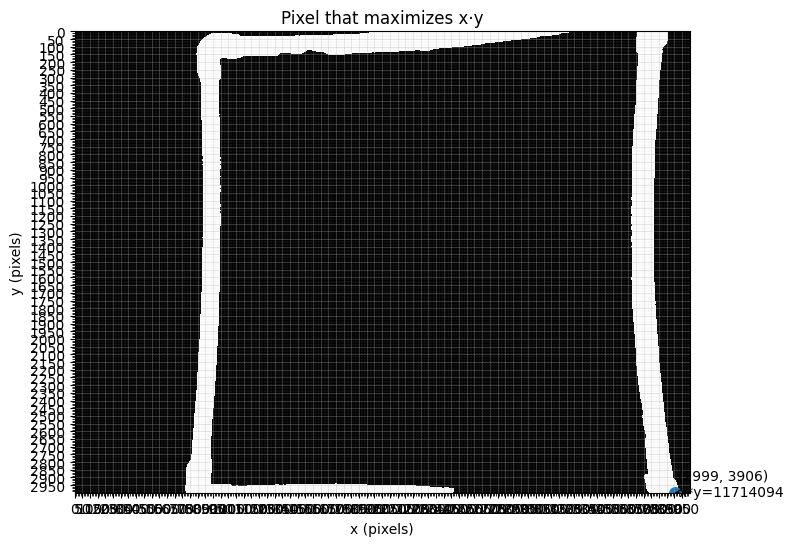

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def load_mask_from_pt(path: str) -> np.ndarray:
    """Load a .pt tensor and return a 2D binary mask (0/1)."""
    t = torch.load(path, map_location="cpu")
    m = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)
    m = (np.squeeze(m) > 0).astype(np.uint8)   # binarize (handles 0/1 or 0/255)
    if m.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {m.shape}")
    return m

def load_mask_from_pt(path: str) -> np.ndarray:
    """Load a .pt tensor and return a 2D binary mask (0/1)."""
    t = torch.load(path, map_location="cpu")
    m = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)
    m = (np.squeeze(m) > 0).astype(np.uint8)   # binarize; handle 0/1 or 0/255
    if m.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {m.shape}")
    return m

def max_xy_pixel(m: np.ndarray) -> tuple[int, int, int]:
    """Return (y, x, product) for the white pixel that maximizes x*y (0-based)."""
    ys, xs = np.where(m == 1)
    if ys.size == 0:
        raise ValueError("Mask is empty (no white pixels).")
    products = ys.astype(np.int64) * xs.astype(np.int64)
    i = int(products.argmax())
    return int(ys[i]), int(xs[i]), int(products[i])

def plot_with_grid(m: np.ndarray, y: int, x: int, title: str = "Pixel that maximizes x·y"):
    """Plot mask with pixel grid and highlight the selected (y, x)."""
    H, W = m.shape
    fig, ax = plt.subplots(figsize=(8, 8 * H / W))
    # Align pixel centers to integer coordinates
    ax.imshow(
        m, cmap="gray", interpolation="nearest", origin="upper",
        extent=(-0.5, W - 0.5, H - 0.5, -0.5)
    )
    ax.scatter([x], [y], s=70)
    ax.annotate(f"({y}, {x})\nx*y={y*x}", xy=(x, y), xytext=(x + 20, y + 20),
                arrowprops=dict(arrowstyle="->"))

    # Pixel grid (majors every 50, minors every 10)
    major, minor = 50, 10
    ax.set_xticks(np.arange(0, W, major))
    ax.set_xticks(np.arange(0, W, minor), minor=True)
    ax.set_yticks(np.arange(0, H, major))
    ax.set_yticks(np.arange(0, H, minor), minor=True)
    ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.20)

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)  # keep (0,0) top-left
    ax.set_aspect("equal")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def max_xy_from_pt(path: str, plot: bool = True) -> tuple[int, int, int]:
    """
    Load a .pt mask, find the white pixel maximizing x*y, optionally plot it.
    Returns (y, x, x*y).
    """
    m = load_mask_from_pt(path)
    y, x, prod = max_xy_pixel(m)
    print({"shape": m.shape, "max_xy_pixel_(y,x)": (y, x), "x*y": prod})
    if plot:
        plot_with_grid(m, y, x)
    return y, x, prod

y, x, prod = max_xy_from_pt("/content/GA 1_PB100637_improved.pt")

## Finding top left

{'shape': (3000, 4000), 'min_xy_pixel_(y,x)': (45, 834), 'x*y': 879}


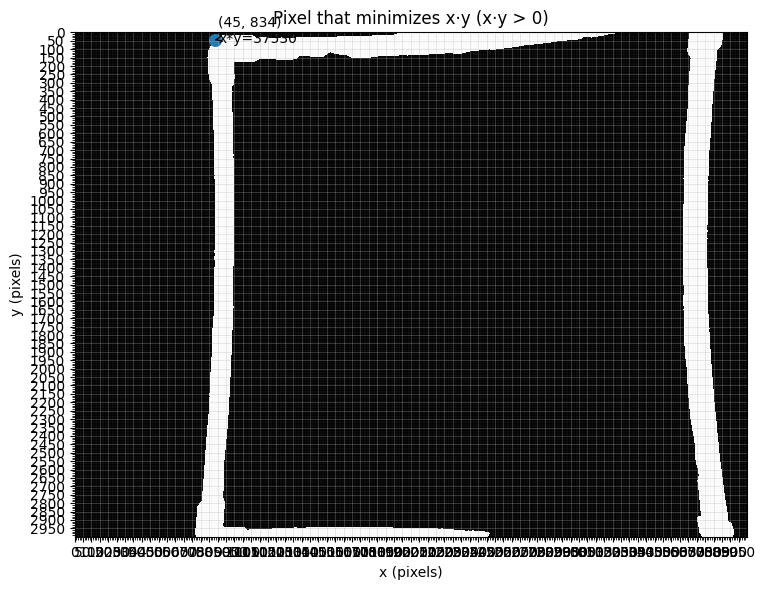

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def load_mask_from_pt(path: str) -> np.ndarray:
    """Load a .pt tensor and return a 2D binary mask (0/1)."""
    t = torch.load(path, map_location="cpu")
    m = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)
    m = (np.squeeze(m) > 0).astype(np.uint8)   # binarize; handle 0/1 or 0/255
    if m.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {m.shape}")
    return m

def min_xy_pixel_pos_product(m: np.ndarray) -> tuple[int, int, int]:
    """
    Return (y, x, product) for the white pixel that minimizes x*y (0-based),
    subject to the constraint x*y > 0 (i.e., x>0 and y>0).

    Tie-break: smallest y, then smallest x among equal products.
    """
    ys, xs = np.where(m == 1)
    if ys.size == 0:
        raise ValueError("Mask is empty (no white pixels).")

    # Enforce x*y > 0  ->  x > 0 and y > 0 (non-negative coordinates)
    pos = (xs > 0) & (ys > 0)
    if not np.any(pos):
        raise ValueError("No white pixels satisfy x*y > 0.")

    ys_p, xs_p = ys[pos].astype(np.int64), xs[pos].astype(np.int64)
    prods = ys_p + xs_p
    min_prod = int(prods.min())

    # Deterministic tie-break
    tie = (prods == min_prod)
    ys_tied, xs_tied = ys_p[tie], xs_p[tie]
    y_min = int(ys_tied.min())
    x_min = int(xs_tied[ys_tied == y_min].min())

    return y_min, x_min, min_prod

def plot_with_grid(m: np.ndarray, y: int, x: int, title: str = "Pixel that minimizes x·y (x·y > 0)"):
    """Plot mask with pixel grid and highlight (y, x)."""
    H, W = m.shape
    fig, ax = plt.subplots(figsize=(8, 8 * H / W))
    # Align pixel centers to integer coordinates
    ax.imshow(
        m, cmap="gray", interpolation="nearest", origin="upper",
        extent=(-0.5, W - 0.5, H - 0.5, -0.5)
    )
    ax.scatter([x], [y], s=70)
    ax.annotate(f"({y}, {x})\nx*y={y*x}", xy=(x, y), xytext=(x + 20, y + 20),
                arrowprops=dict(arrowstyle="->"))

    # Pixel grid (majors every 50, minors every 10)
    major, minor = 50, 10
    ax.set_xticks(np.arange(0, W, major))
    ax.set_xticks(np.arange(0, W, minor), minor=True)
    ax.set_yticks(np.arange(0, H, major))
    ax.set_yticks(np.arange(0, H, minor), minor=True)
    ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.20)

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)  # keep (0,0) at top-left
    ax.set_aspect("equal")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def min_xy_from_pt_pos(path: str, plot: bool = True) -> tuple[int, int, int]:
    """
    Load a .pt mask, find the white pixel minimizing x*y with constraint x*y > 0,
    optionally plot it. Returns (y, x, x*y).
    """
    m = load_mask_from_pt(path)
    y, x, prod = min_xy_pixel_pos_product(m)
    print({"shape": m.shape, "min_xy_pixel_(y,x)": (y, x), "x*y": prod})
    if plot:
        plot_with_grid(m, y, x)
    return y, x, prod


y, x, prod = min_xy_from_pt_pos("/content/GA 1_PB100637_improved.pt")

## Top right

{'shape': (3000, 4000), 'max_(x_minus_y)_(y,x)': (0, 3850), 'x_minus_y': 3850}


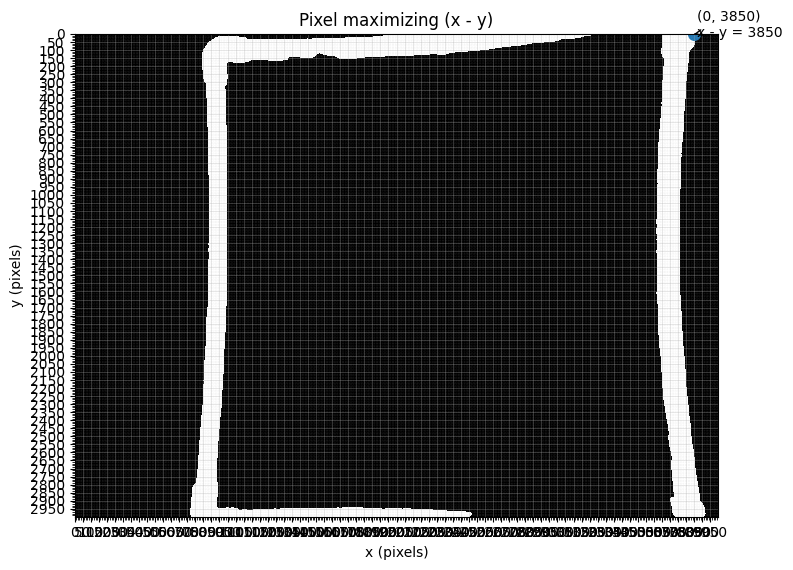

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Load helper --------------------------------------------------------------
def load_mask_from_pt(path: str) -> np.ndarray:
    """Load a .pt tensor and return a 2D binary mask (0/1)."""
    t = torch.load(path, map_location="cpu")
    m = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)
    m = (np.squeeze(m) > 0).astype(np.uint8)   # binarize; works for 0/1 or 0/255
    if m.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {m.shape}")
    return m

# --- Core selection: maximize x - y -------------------------------------------
def max_x_minus_y_pixel(m: np.ndarray) -> tuple[int, int, int]:
    """
    Return (y, x, x_minus_y) for the white pixel that maximizes (x - y).
    Tie-break (deterministic): among equal (x - y), choose largest x, then smallest y.
    """
    ys, xs = np.where(m == 1)
    if ys.size == 0:
        raise ValueError("Mask is empty (no white pixels).")

    diffs = xs.astype(np.int64) - ys.astype(np.int64)
    best = diffs.max()

    idx = np.where(diffs == best)[0]
    xs_t, ys_t = xs[idx], ys[idx]

    # Tie-break: largest x first
    x_sel = xs_t.max()
    # Among those, smallest y
    y_sel = ys_t[xs_t == x_sel].min()

    return int(y_sel), int(x_sel), int(best)

# --- Plotting with pixel grid -------------------------------------------------
def plot_with_grid(m: np.ndarray, y: int, x: int, title: str = "Pixel maximizing (x - y)"):
    H, W = m.shape
    fig, ax = plt.subplots(figsize=(8, 8 * H / W))

    # Align pixel centers to integer coords
    ax.imshow(
        m, cmap="gray", interpolation="nearest", origin="upper",
        extent=(-0.5, W - 0.5, H - 0.5, -0.5)
    )
    ax.scatter([x], [y], s=70)
    ax.annotate(f"({y}, {x})\nx - y = {x - y}", xy=(x, y), xytext=(x + 20, y + 20),
                arrowprops=dict(arrowstyle="->"))

    # Pixel grid (majors every 50, minors every 10)
    major, minor = 50, 10
    ax.set_xticks(np.arange(0, W, major))
    ax.set_xticks(np.arange(0, W, minor), minor=True)
    ax.set_yticks(np.arange(0, H, major))
    ax.set_yticks(np.arange(0, H, minor), minor=True)
    ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.20)

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)  # keep (0,0) at top-left
    ax.set_aspect("equal")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# --- Convenience wrapper for .pt files ---------------------------------------
def max_x_minus_y_from_pt(path: str, plot: bool = True) -> tuple[int, int, int]:
    """
    Load a .pt mask, find the white pixel maximizing (x - y), optionally plot it.
    Returns (y, x, x_minus_y).
    """
    m = load_mask_from_pt(path)
    y, x, diff = max_x_minus_y_pixel(m)
    print({"shape": m.shape, "max_(x_minus_y)_(y,x)": (y, x), "x_minus_y": diff})
    if plot:
        plot_with_grid(m, y, x)
    return y, x, diff

# Example:
y, x, diff = max_x_minus_y_from_pt("/content/GA 1_PB100637_improved.pt", plot=True)

## Bottom left

{'shape': (3000, 4000), 'max_(y_minus_x)_(y,x)': (2999, 902), 'y_minus_x': 2097}


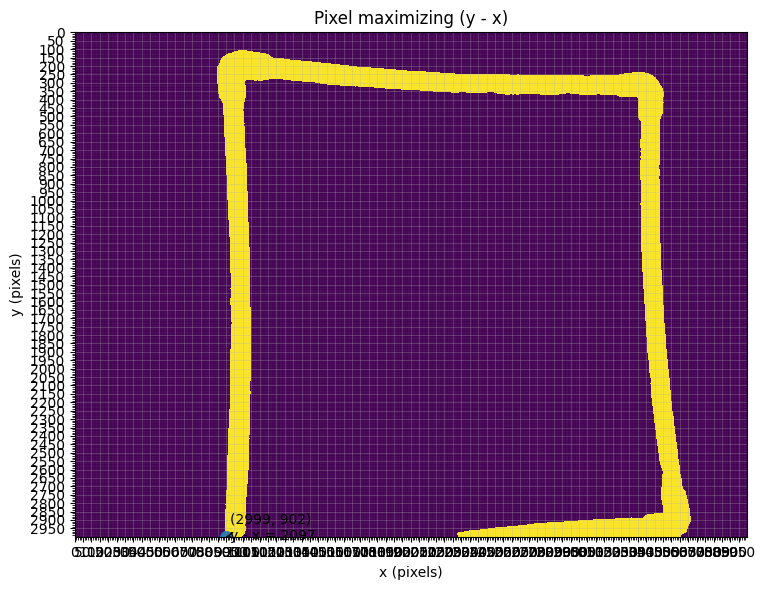

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Load helper --------------------------------------------------------------
def load_mask_from_pt(path: str) -> np.ndarray:
    """Load a .pt tensor and return a 2D binary mask (0/1)."""
    t = torch.load(path, map_location="cpu")
    m = t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)
    m = (np.squeeze(m) > 0).astype(np.uint8)   # binarize (handles 0/1 or 0/255)
    if m.ndim != 2:
        raise ValueError(f"Expected 2D mask, got shape {m.shape}")
    return m

# --- Core selection: maximize (y - x) -----------------------------------------
def max_y_minus_x_pixel(m: np.ndarray) -> tuple[int, int, int]:
    """
    Return (y, x, y_minus_x) for the white pixel that maximizes (y - x).
    Tie-break (deterministic): among equal (y - x), choose largest y, then smallest x.
    """
    ys, xs = np.where(m == 1)
    if ys.size == 0:
        raise ValueError("Mask is empty (no white pixels).")

    diffs = ys.astype(np.int64) - xs.astype(np.int64)
    best = int(diffs.max())

    idx = np.where(diffs == best)[0]
    ys_t, xs_t = ys[idx], xs[idx]

    y_sel = int(ys_t.max())                       # lowest (max y) among ties
    x_sel = int(xs_t[ys_t == y_sel].min())        # leftmost among those
    return y_sel, x_sel, best

# --- Plotting with pixel grid -------------------------------------------------
def plot_with_grid(m: np.ndarray, y: int, x: int, title: str = "Pixel maximizing (y - x)"):
    H, W = m.shape
    fig, ax = plt.subplots(figsize=(8, 8 * H / W))

    # Align pixel centers to integer coordinates
    ax.imshow(
        m, interpolation="nearest", origin="upper",
        extent=(-0.5, W - 0.5, H - 0.5, -0.5)
    )
    ax.scatter([x], [y], s=70)
    ax.annotate(f"({y}, {x})\ny - x = {y - x}", xy=(x, y), xytext=(x + 20, y + 20),
                arrowprops=dict(arrowstyle="->"))

    # Pixel grid (majors every 50, minors every 10)
    major, minor = 50, 10
    ax.set_xticks(np.arange(0, W, major))
    ax.set_xticks(np.arange(0, W, minor), minor=True)
    ax.set_yticks(np.arange(0, H, major))
    ax.set_yticks(np.arange(0, H, minor), minor=True)
    ax.grid(which="major", linestyle="-", linewidth=0.6, alpha=0.35)
    ax.grid(which="minor", linestyle=":", linewidth=0.4, alpha=0.20)

    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)  # keep (0,0) top-left
    ax.set_aspect("equal")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# --- Convenience wrapper for .pt files ---------------------------------------
def max_y_minus_x_from_pt(path: str, plot: bool = True) -> tuple[int, int, int]:
    """
    Load a .pt mask, find the white pixel maximizing (y - x), optionally plot it.
    Returns (y, x, y_minus_x).
    """
    m = load_mask_from_pt(path)
    y, x, diff = max_y_minus_x_pixel(m)
    print({"shape": m.shape, "max_(y_minus_x)_(y,x)": (y, x), "y_minus_x": diff})
    if plot:
        plot_with_grid(m, y, x)
    return y, x, diff

# Example:
y, x, diff = max_y_minus_x_from_pt("/content/GA 1_PB100653_improved.pt", plot=True)